In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ImportError:
    print("Seaborn not found, using default matplotlib style.")
    plt.style.use('ggplot')

plt.rcParams['figure.figsize'] = [12, 6]


In [2]:
# Rutes ABSOLUTES als fitxers
import os

base_dir = r"c:\Users\ferri\Documents\ProjectesCodi\TFG-truc\entrenament\entrenamentsUnificats\registres\resultats_dqn"

experiments = {
    "Finetune": os.path.join(base_dir, "dqn_finetune_0703_0059", "logs", "dqn_finetune.csv"),
    "Frozen": os.path.join(base_dir, "dqn_frozen_0603_2342", "logs", "dqn_frozen.csv"),
    "Scratch": os.path.join(base_dir, "dqn_scratch_0603_2130", "logs", "dqn_scratch.csv")
}

dfs = []
for name, path in experiments.items():
    if os.path.exists(path):
        df = pd.read_csv(path)
        df['Experiment'] = name
        dfs.append(df)
    else:
        print(f"Advertència: No s'ha trobat el fitxer {path}")

if dfs:
    df_all = pd.concat(dfs, ignore_index=True)
    display(df_all.head())
else:
    print("Error: No s'ha carregat cap dada.")


,ep,reward,vic%,best,lr,Experiment
0,1000,0.673167,83.7,0.673167,0.0005,Finetune
1,2000,0.654500,82.7,0.673167,0.0005,Finetune
2,3000,0.715500,85.8,0.715500,0.0005,Finetune
3,4000,0.652167,82.6,0.715500,0.0005,Finetune
4,5000,0.700167,85.0,0.715500,0.0005,Finetune


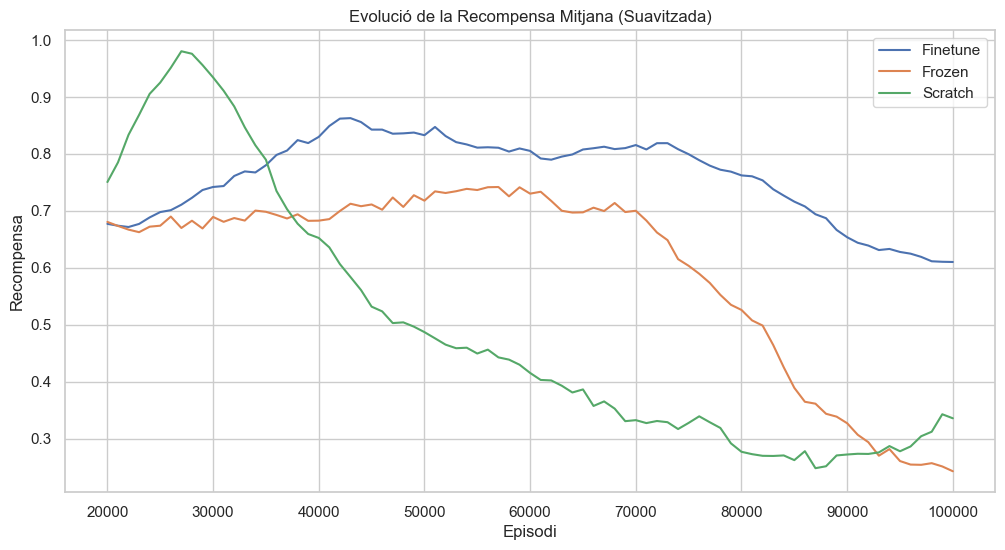

In [3]:
# Plot de Recompensa (Smoothed)
def plot_smoothed(df, column, title, ylabel, window=20):
    plt.figure()
    for name in df['Experiment'].unique():
        data = df[df['Experiment'] == name]
        smoothed = data[column].rolling(window=window).mean()
        plt.plot(data['ep'], smoothed, label=name)
    
    plt.title(title)
    plt.xlabel('Episodi')
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()

plot_smoothed(df_all, 'reward', 'Evolució de la Recompensa Mitjana (Suavitzada)', 'Recompensa')


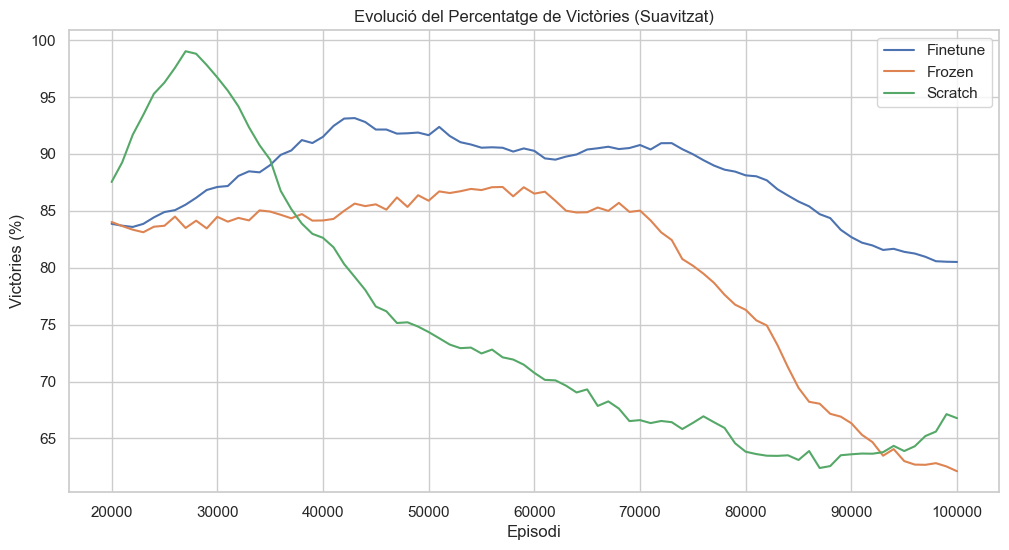

In [4]:
# Plot de Percentatge de Victòries
plot_smoothed(df_all, 'vic%', 'Evolució del Percentatge de Victòries (Suavitzat)', 'Victòries (%)')


In [5]:
# Configuració de la lliga amb paths absoluts
import sys
import torch
import numpy as np
from pathlib import Path

# Afegir l'arrel del projecte al path
project_root = r"c:\Users\ferri\Documents\ProjectesCodi\TFG-truc"
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from rlcard.utils import set_seed
from entorn import TrucEnv
from rlcard.agents import DQNAgent
from entrenament.entrenamentsUnificats.entrenaments_unificats import wrap_env_aplanat, AgentCongelat, init_dqn, carregar_pesos

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ENV_CONFIG = {
    'num_jugadors': 2,
    'cartes_jugador': 3,
    'puntuacio_final': 12, 
    'seed': 42,
    'verbose': False,
}

base_dir = r"c:\Users\ferri\Documents\ProjectesCodi\TFG-truc\entrenament\entrenamentsUnificats\registres\resultats_dqn"

model_paths = {
    "Finetune": os.path.join(base_dir, "dqn_finetune_0703_0059", "models", "best.pt"),
    "Frozen": os.path.join(base_dir, "dqn_frozen_0603_2342", "models", "best.pt"),
    "Scratch": os.path.join(base_dir, "dqn_scratch_0603_2130", "models", "best.pt")
}

def load_model_agent(name, path, env):
    agent = init_dqn(env, device, "frozen") 
    carregar_pesos(agent, path, device)
    return AgentCongelat(agent)

env_league = wrap_env_aplanat(TrucEnv(ENV_CONFIG))
agents = {}
for name, path in model_paths.items():
    if os.path.exists(path):
        print(f"Carregant {name} des de {path}...")
        agents[name] = load_model_agent(name, path, env_league)
    else:
        print(f"Model no trobat per {name}: {path}")


Carregant Finetune des de c:\Users\ferri\Documents\ProjectesCodi\TFG-truc\entrenament\entrenamentsUnificats\registres\resultats_dqn\dqn_finetune_0703_0059\models\best.pt...[XarxaUnificada] Pesos carregats: 05_03_26_a_les_0015
Pesos de l'MLP carregats correctament des de best.pt
Carregant Frozen des de c:\Users\ferri\Documents\ProjectesCodi\TFG-truc\entrenament\entrenamentsUnificats\registres\resultats_dqn\dqn_frozen_0603_2342\models\best.pt...[XarxaUnificada] Pesos carregats: 05_03_26_a_les_0015
Pesos de l'MLP carregats correctament des de best.pt
Carregant Scratch des de c:\Users\ferri\Documents\ProjectesCodi\TFG-truc\entrenament\entrenamentsUnificats\registres\resultats_dqn\dqn_scratch_0603_2130\models\best.pt...[XarxaUnificada] Pesos carregats: 05_03_26_a_les_0015
Pesos de l'MLP carregats correctament des de best.pt

In [6]:
def jugar_partida(agent0, agent1, env):
    env.set_agents([agent0, agent1])
    _, payoffs = env.run(is_training=False)
    # payoffs[0] > 0 significa que agent0 guanya
    return 1 if payoffs[0] > 0 else 0

def simular_lliga(agents, env, num_partides_per_parella=2):
    resultats = []
    names = list(agents.keys())
    for i in range(len(names)):
        for j in range(len(names)):
            if i == j: continue
            
            m1_name = names[i]
            m2_name = names[j]
            
            wins_m1 = 0
            for _ in range(num_partides_per_parella):
               wins_m1 += jugar_partida(agents[m1_name], agents[m2_name], env)
            
            resultats.append({
                "Local": m1_name,
                "Visitant": m2_name,
                "Victòries Local": wins_m1,
                "Partides": num_partides_per_parella
            })
    return pd.DataFrame(resultats)

# Simulem la lliga N vegades per obtenir una mitjana
num_simulacions = 10
lligues = []

print(f"Iniciant {num_simulacions} simulaions de la Lliga...")
for s in range(num_simulacions):
    print(f"Simulació {s+1}/{num_simulacions}...")
    df_s = simular_lliga(agents, env_league)
    df_s['Simulació'] = s
    lligues.append(df_s)

df_league_all = pd.concat(lligues, ignore_index=True)
display(df_league_all.head())


Iniciant 10 simulaions de la Lliga...
Simulació 1/10...Simulació 2/10...Simulació 3/10...Simulació 4/10...Simulació 5/10...Simulació 6/10...Simulació 7/10...Simulació 8/10...Simulació 9/10...Simulació 10/10...

,Local,Visitant,Victòries Local,Partides,Simulació
0,Finetune,Frozen,2,2,0
1,Finetune,Scratch,1,2,0
2,Frozen,Finetune,0,2,0
3,Frozen,Scratch,0,2,0
4,Scratch,Finetune,1,2,0


In [7]:
# Leaderboard final mitjà
# Primer sumem victòries per simulació i model
per_simulacio = df_league_all.groupby(["Simulació", "Local"])["Victòries Local"].sum().reset_index()

# Ara fem la mitjana entre simulacions
leaderboard_mitja = per_simulacio.groupby("Local")["Victòries Local"].agg(['mean', 'std']).reset_index()
leaderboard_mitja.columns = ["Model", "Mitjana Victòries", "Desviació Típica"]
leaderboard_mitja = leaderboard_mitja.sort_values(by="Mitjana Victòries", ascending=False)

print("\nLeaderboard Final (Mitjana de 5 lligues):")
display(leaderboard_mitja)



Leaderboard Final (Mitjana de 5 lligues):

,Model,Mitjana Victòries,Desviació Típica
2,Scratch,3.4,0.699206
0,Finetune,3.0,0.666667
1,Frozen,0.2,0.421637
